FAILURE RATE BY MECHANICAL-POWER REGIME


,observations,failures,failure_rate
Power Regime,,,
Low,2501,49,1.96%
Medium-Low,2499,22,0.88%
Medium-High,2500,45,1.80%
High,2500,223,8.92%



FAILURE RATE BY TOOL-WEAR REGIME


,observations,failures,failure_rate
Tool Wear Regime,,,
Low Wear,2529,55,2.17%
Medium-Low Wear,2499,59,2.36%
Medium-High Wear,2476,52,2.10%
High Wear,2496,173,6.93%



FAILURE RATE — TOOL WEAR × MECHANICAL POWER


Power Regime,Low,Medium-Low,Medium-High,High
Tool Wear Regime,,,,
Low Wear,1.20%,0.33%,1.26%,5.99%
Medium-Low Wear,1.72%,0.16%,1.41%,6.09%
Medium-High Wear,1.44%,0.00%,1.28%,5.77%
High Wear,3.53%,2.99%,3.33%,17.64%


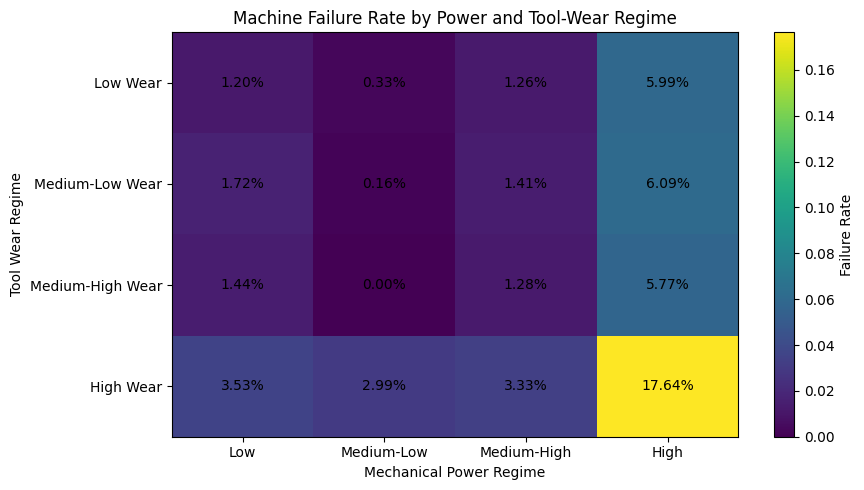


OPERATING-REGIME ANALYSIS
The tables above show how observed failure rates change across mechanical-power and tool-wear operating regimes.
These regime comparisons are descriptive and should not be interpreted as proof of causation.


In [13]:
# ============================================================
# Step 5 — Operating-Regime & Failure-Risk Analysis
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
# Create operating-regime bins using quartiles
df["Power Regime"] = pd.qcut(
    df["Mechanical Power [kW]"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

df["Tool Wear Regime"] = pd.qcut(
    df["Tool wear [min]"],
    q=4,
    labels=["Low Wear", "Medium-Low Wear", "Medium-High Wear", "High Wear"]
)

# ------------------------------------------------------------
# 1. Failure rate by mechanical-power regime
# ------------------------------------------------------------

power_risk = df.groupby("Power Regime", observed=False).agg(
    observations=("Machine failure", "size"),
    failures=("Machine failure", "sum"),
    failure_rate=("Machine failure", "mean")
)

print("FAILURE RATE BY MECHANICAL-POWER REGIME")
display(power_risk.style.format({"failure_rate": "{:.2%}"}))


# ------------------------------------------------------------
# 2. Failure rate by tool-wear regime
# ------------------------------------------------------------

wear_risk = df.groupby("Tool Wear Regime", observed=False).agg(
    observations=("Machine failure", "size"),
    failures=("Machine failure", "sum"),
    failure_rate=("Machine failure", "mean")
)

print("\nFAILURE RATE BY TOOL-WEAR REGIME")
display(wear_risk.style.format({"failure_rate": "{:.2%}"}))


# ------------------------------------------------------------
# 3. Combined power + tool-wear operating regimes
# ------------------------------------------------------------

regime_risk = pd.pivot_table(
    df,
    values="Machine failure",
    index="Tool Wear Regime",
    columns="Power Regime",
    aggfunc="mean",
    observed=False
)

print("\nFAILURE RATE — TOOL WEAR × MECHANICAL POWER")
display(regime_risk.style.format("{:.2%}"))


# ------------------------------------------------------------
# 4. Visualize the combined operating regimes
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    regime_risk.values,
    aspect="auto"
)

ax.set_xticks(range(len(regime_risk.columns)))
ax.set_xticklabels(regime_risk.columns)

ax.set_yticks(range(len(regime_risk.index)))
ax.set_yticklabels(regime_risk.index)

ax.set_xlabel("Mechanical Power Regime")
ax.set_ylabel("Tool Wear Regime")
ax.set_title("Machine Failure Rate by Power and Tool-Wear Regime")

for i in range(regime_risk.shape[0]):
    for j in range(regime_risk.shape[1]):
        value = regime_risk.iloc[i, j]
        if not pd.isna(value):
            ax.text(j, i, f"{value:.2%}", ha="center", va="center")

plt.colorbar(im, ax=ax, label="Failure Rate")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Engineering interpretation
# ------------------------------------------------------------

print("\nOPERATING-REGIME ANALYSIS")
print(
    "The tables above show how observed failure rates change across "
    "mechanical-power and tool-wear operating regimes."
)
print(
    "These regime comparisons are descriptive and should not be interpreted "
    "as proof of causation."
)

## Engineering Interpretation — Operating Regimes

The operating-regime analysis shows that machine failures are not evenly distributed across operating conditions. The highest mechanical-power regime has a substantially higher observed failure rate than the lower-power regimes.

The combined power and tool-wear analysis indicates an elevated observed failure rate in the high-power/high-wear operating region. This suggests that the interaction between mechanical loading and accumulated tool wear may contain useful predictive information.

These findings represent associations observed in the dataset and should not be interpreted as proof of causation. The identified relationships will be evaluated further during feature engineering and predictive modeling.

In [14]:
# ============================================================
# Step 6 — Feature Engineering & ML Dataset Preparation
# ============================================================

# Candidate predictive features
candidate_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Angular Speed [rad/s]",
    "Mechanical Power [kW]"
]

target = "Machine failure"

# Columns intentionally excluded
excluded_columns = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Create the model-ready feature table
X = df[candidate_features].copy()
y = df[target].copy()

print("MODEL INPUT FEATURES")
display(pd.DataFrame({
    "Feature": candidate_features,
    "Data Type": X.dtypes.astype(str).values
}))

print("\nTARGET")
print(f"Target variable: {target}")
print(f"Target observations: {len(y):,}")
print(f"Failure cases: {int(y.sum()):,}")
print(f"Failure rate: {y.mean():.2%}")

print("\nEXCLUDED FROM PREDICTIVE FEATURES")
print(excluded_columns)

print("\nMODEL DATASET SHAPE")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

MODEL INPUT FEATURES


,Feature,Data Type
0,Type,object
1,Air temperature [K],float64
2,Process temperature [K],float64
3,Rotational speed [rpm],int64
4,Torque [Nm],float64
5,Tool wear [min],int64
6,Temperature Difference [K],float64
7,Angular Speed [rad/s],float64
8,Mechanical Power [kW],float64



TARGET
Target variable: Machine failure
Target observations: 10,000
Failure cases: 339
Failure rate: 3.39%

EXCLUDED FROM PREDICTIVE FEATURES
['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

MODEL DATASET SHAPE
X shape: (10000, 9)
y shape: (10000,)


In [15]:
# Step 7 — Train/Test Split & Baseline Logistic Regression

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_PATH = "/kaggle/input/datasets/sayoojkp741/ai4i-2020-predictive-maintenance-dataset/ai4i2020.csv.csv"

df = pd.read_csv(DATA_PATH)

df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Angular Speed [rad/s]"] = (
    2 * np.pi * df["Rotational speed [rpm]"] / 60
)

df["Mechanical Power [kW]"] = (
    df["Torque [Nm]"] * df["Angular Speed [rad/s]"] / 1000
)

features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Angular Speed [rad/s]",
    "Mechanical Power [kW]"
]

X = df[features]
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Angular Speed [rad/s]",
    "Mechanical Power [kW]"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("TRAIN / TEST SPLIT")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"Training failure rate: {y_train.mean():.2%}")
print(f"Testing failure rate: {y_test.mean():.2%}")

print("\nCLASSIFICATION REPORT")
print(classification_report(
    y_test, y_pred,
    digits=3,
    zero_division=0
))

print("CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob):.3f}")

TRAIN / TEST SPLIT
Training samples: 8,000
Testing samples: 2,000
Training failure rate: 3.39%
Testing failure rate: 3.40%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.995     0.858     0.921      1932
           1      0.177     0.868     0.294        68

    accuracy                          0.859      2000
   macro avg      0.586     0.863     0.608      2000
weighted avg      0.967     0.859     0.900      2000

CONFUSION MATRIX
[[1658  274]
 [   9   59]]

ROC-AUC: 0.934
PR-AUC: 0.466


MODEL COMPARISON
                 Model  ROC-AUC  PR-AUC
0  Logistic Regression    0.934   0.466
1        Random Forest    0.963   0.856

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0      0.991     0.997     0.994      1932
           1      0.909     0.735     0.813        68

    accuracy                          0.989      2000
   macro avg      0.950     0.866     0.904      2000
weighted avg      0.988     0.989     0.988      2000

CONFUSION MATRIX
[[1927    5]
 [  18   50]]

Random Forest ROC-AUC: 0.963
Random Forest PR-AUC: 0.856

TOP PREDICTIVE FEATURES
                            Feature  Importance
           numeric__Tool wear [min]      0.1975
    numeric__Rotational speed [rpm]      0.1710
               numeric__Torque [Nm]      0.1687
     numeric__Mechanical Power [kW]      0.1648
     numeric__Angular Speed [rad/s]      0.1375
numeric__Temperature Difference [K]      0.0708
       numeric__Air temperature [K] 

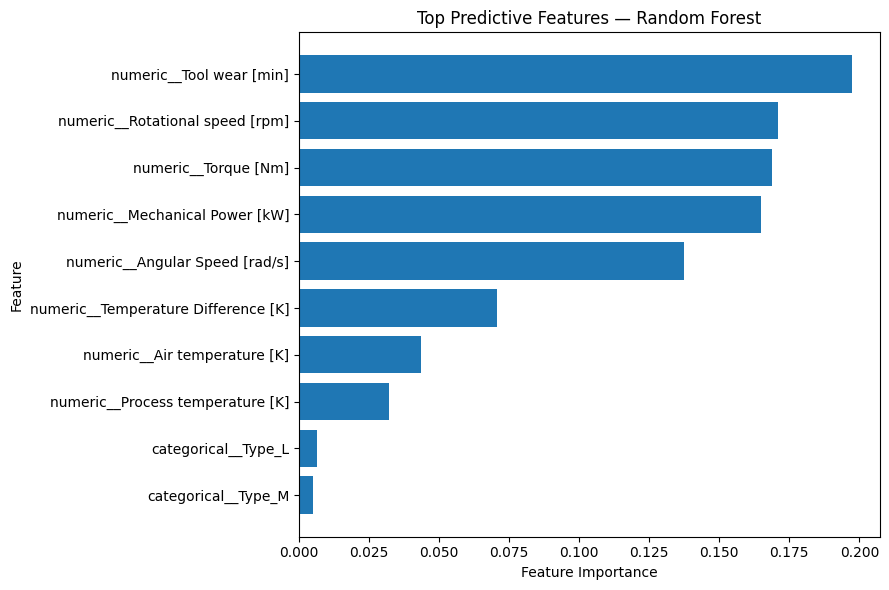


PREDICTIVE MAINTENANCE RISK SEGMENTS
Risk Level
Low Risk       1905
Medium Risk      40
High Risk        55
Name: count, dtype: int64

Observed failure rate by predicted risk:
Risk Level
Low Risk        0.52
Medium Risk    20.00
High Risk      90.91
Name: Actual Failure, dtype: float64

PROJECT OUTPUT FILES CREATED
✓ model_comparison.csv
✓ predictive_maintenance_risk_scores.csv

Predictive maintenance analysis completed successfully.


In [1]:
# ============================================================
# STEP 8 — FINAL PREDICTIVE MAINTENANCE MODEL
# Random Forest + Risk Analysis + Feature Importance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

DATA_PATH = "/kaggle/input/datasets/sayoojkp741/ai4i-2020-predictive-maintenance-dataset/ai4i2020.csv.csv"

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# 2. Engineering feature creation
# ------------------------------------------------------------

df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Angular Speed [rad/s]"] = (
    2 * np.pi * df["Rotational speed [rpm]"] / 60
)

df["Mechanical Power [kW]"] = (
    df["Torque [Nm]"] * df["Angular Speed [rad/s]"] / 1000
)

# ------------------------------------------------------------
# 3. Predictive features
# ------------------------------------------------------------

features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Angular Speed [rad/s]",
    "Mechanical Power [kW]"
]

X = df[features]
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Angular Speed [rad/s]",
    "Mechanical Power [kW]"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 4. Logistic Regression baseline
# ------------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.5).astype(int)

logistic_roc = roc_auc_score(y_test, logistic_prob)
logistic_pr = average_precision_score(y_test, logistic_prob)

# ------------------------------------------------------------
# 5. Random Forest model
# ------------------------------------------------------------

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)

# ------------------------------------------------------------
# 6. Model comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        logistic_roc,
        rf_roc
    ],
    "PR-AUC": [
        logistic_pr,
        rf_pr
    ]
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison.round(3))

# ------------------------------------------------------------
# 7. Random Forest classification results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        digits=3,
        zero_division=0
    )
)

print("CONFUSION MATRIX")
print(confusion_matrix(y_test, rf_pred))

print(f"\nRandom Forest ROC-AUC: {rf_roc:.3f}")
print(f"Random Forest PR-AUC: {rf_pr:.3f}")

# ------------------------------------------------------------
# 8. Feature importance
# ------------------------------------------------------------

feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = rf_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

print("\n" + "=" * 60)
print("TOP PREDICTIVE FEATURES")
print("=" * 60)

print(
    feature_importance.head(10).round(4).to_string(
        index=False
    )
)

# Plot top features
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Predictive Features — Random Forest")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Failure-risk scoring
# ------------------------------------------------------------

risk_df = X_test.copy()

risk_df["Actual Failure"] = y_test.values
risk_df["Predicted Failure Probability"] = rf_prob

risk_df["Risk Level"] = pd.cut(
    risk_df["Predicted Failure Probability"],
    bins=[-0.01, 0.20, 0.50, 1.01],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

print("\n" + "=" * 60)
print("PREDICTIVE MAINTENANCE RISK SEGMENTS")
print("=" * 60)

print(
    risk_df["Risk Level"]
    .value_counts()
    .sort_index()
)

print("\nObserved failure rate by predicted risk:")
print(
    risk_df.groupby(
        "Risk Level",
        observed=True
    )["Actual Failure"]
    .mean()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# 10. Save portfolio outputs
# ------------------------------------------------------------

comparison.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

risk_df.to_csv(
    "/kaggle/working/predictive_maintenance_risk_scores.csv",
    index=False
)

print("\n" + "=" * 60)
print("PROJECT OUTPUT FILES CREATED")
print("=" * 60)

print("✓ model_comparison.csv")
print("✓ predictive_maintenance_risk_scores.csv")
print("\nPredictive maintenance analysis completed successfully.")

# Final Engineering & Predictive Maintenance Conclusions

## Project Objective

This project develops an engineering-focused machine learning workflow for predicting machine failure risk using the UCI AI4I 2020 Predictive Maintenance dataset.

## Key Engineering Findings

- Machine failures represent a minority of observations, making class imbalance an important modeling consideration.
- Mechanical Power was derived from torque and rotational speed to provide an engineering-relevant operating feature.
- Higher operating power and higher tool wear were associated with increased observed failure rates.
- Tool wear, rotational speed, torque, and mechanical power were among the most important predictive features in the Random Forest model.

## Machine Learning Results

Two classification approaches were evaluated:

- Logistic Regression: ROC-AUC = 0.934, PR-AUC = 0.466
- Random Forest: ROC-AUC = 0.963, PR-AUC = 0.856

The Random Forest provided stronger predictive performance on the test set, particularly in precision-recall performance for the minority failure class.

## Predictive Maintenance Application

The final model generates a failure probability for each machine observation and converts the probability into Low, Medium, and High Risk categories.

The observed failure rate increased substantially across the predicted risk groups, demonstrating how the model can support maintenance prioritization.

## Engineering Interpretation

The model should be used as a decision-support tool rather than as a replacement for engineering inspection. High-risk predictions can be used to prioritize equipment inspection, maintenance planning, and further investigation of operating conditions.

## Important Modeling Considerations

Identifier fields were excluded from predictive modeling. Failure-mode indicators were also excluded because they may represent information available only after or during a failure event and could introduce target leakage.

The observed relationships are associations in the dataset and should not be interpreted as proof of physical causation.

## Skills Demonstrated

Python • Pandas • NumPy • Scikit-learn • Machine Learning • Predictive Maintenance • Feature Engineering • Imbalanced Classification • Model Evaluation • Engineering Data Analysis • Risk Scoring